11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 32ms/step - accuracy: 0.8836 - loss: 0.3723 - val_accuracy: 0.9865 - val_loss: 0.0480
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.9843 - loss: 0.0520 - val_accuracy: 0.9865 - val_loss: 0.0424
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9900 - loss: 0.0344 - val_accuracy: 0.9902 - val_loss: 0.0363
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 84s 32ms/step - accuracy: 0.9923 - loss: 0.0241 - val_accuracy: 0.9885 - val_loss: 0.0428
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 50s 30ms/step - accuracy: 0.9936 - loss: 0.0204 - val_accuracy: 0.9917 - val_loss: 0.0351
313/313 - 2s - 8ms/step - accuracy: 0.9927 - loss: 0.0268

Test accuracy: 0.99
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


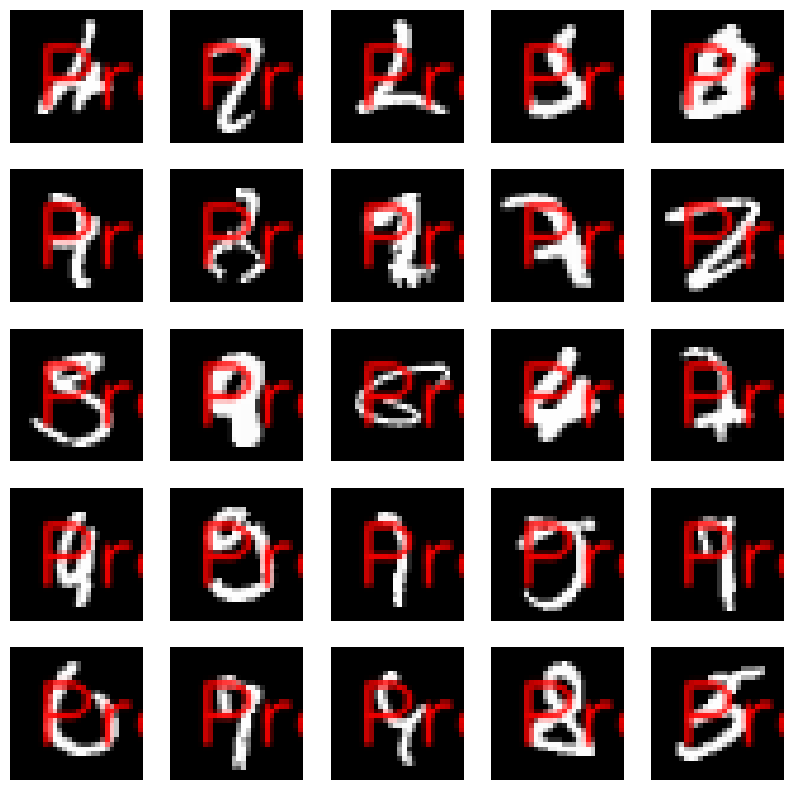

In [2]:
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Загрузка и предобработка данных MNIST
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # Нормализация данных

# Добавление канала (для сверточной сети требуется 3D-формат входных данных)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Создание модели сверточной нейронной сети
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Компиляция модели
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Обучение модели
model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# Оценка точности модели на тестовом наборе
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc:.2f}')

# Предсказание на тестовых данных
predictions = model.predict(x_test)



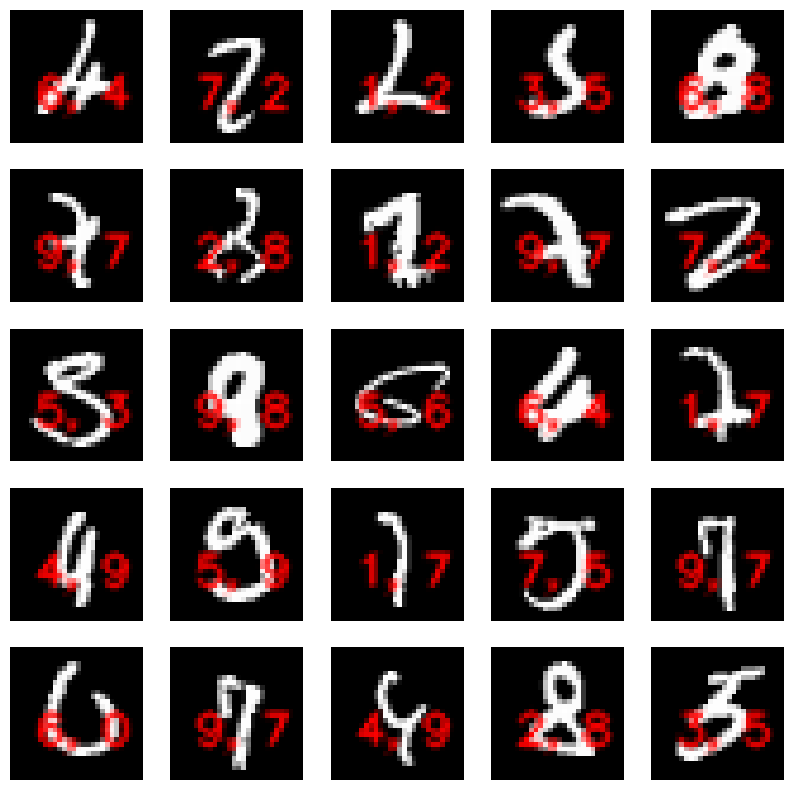

In [8]:
# Поиск и отображение неверно предсказанных изображений
incorrect_indices = np.where(np.argmax(predictions, axis=1) != y_test)[0]
plt.figure(figsize=(10, 10))

for i, idx in enumerate(incorrect_indices[:25]):  # Покажем 25 неверных предсказаний
    img = x_test[idx].reshape(28, 28)
    img = (img * 255).astype(np.uint8)  # Преобразуем к формату uint8 для OpenCV

    # Предсказанный и правильный классы
    predicted_label = np.argmax(predictions[idx])
    true_label = y_test[idx]

    # Используем OpenCV для отображения изображения с предсказанием
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    cv2.putText(img_rgb, f"{predicted_label}, {true_label}", (5, 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255, 0, 0), 1, cv2.LINE_AA)

    plt.subplot(5, 5, i + 1)
    plt.imshow(img_rgb)
    plt.axis('off')

plt.show()